In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def survive_exactly(death_chance, p):
    ''' Probability of surviving exactly to time step p given a constant 
        death_chance independent at each step.'''
        
    return (1-death_chance)**(p-1)*death_chance

In [13]:
def recursive_pop(n_periods, death_chance, birth_rate, pop):
    ''' Recursive function for popualtion growth with contstant birth rate and
        independent death chance'''

    p_function = []
    for i in range(0,n_periods):
        pop = pop*(1-death_chance)+birth_rate
        p_function.append(pop)
    return p_function

In [14]:
pop = pd.Series(recursive_pop(20, 0.1, 2, 0))
pop

0      2.000000
1      3.800000
2      5.420000
3      6.878000
4      8.190200
5      9.371180
6     10.434062
7     11.390656
8     12.251590
9     13.026431
10    13.723788
11    14.351409
12    14.916268
13    15.424642
14    15.882177
15    16.293960
16    16.664564
17    16.998107
18    17.298297
19    17.568467
dtype: float64

In [15]:

[survive_exactly(0.1, t) for t in range(1,4)]

[0.1, 0.09000000000000001, 0.08100000000000002]

In [16]:
[sum(survive_exactly(0.1, t)  for t in range(1,i)) for i in range(1, 6) ]

[0, 0.1, 0.19, 0.271, 0.34390000000000004]

## Looking for equation that gives total deaths at time $t$

In [22]:
start_pop = 0
birth_rate = 1
death_chance = 0.1
n_periods = 10

In [27]:
total_deaths = pd.Series(sum((start_pop + i * birth_rate) * death_chance) for t in range(1, n_periods) for i in range(1, t) )
total_deaths[:10]


TypeError: 'float' object is not iterable

In [19]:
plt.plot(total_deaths)
plt.show()

NameError: name 'total_deaths' is not defined

In [20]:
total_births = pd.Series([(start_pop + t * birth_rate) for t in range(1,100)])
total_births[:10]

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
dtype: int64

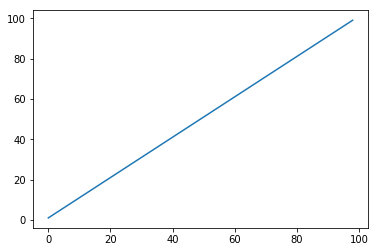

In [21]:
plt.plot(total_births)
plt.show()

In [236]:
total_pop = total_births - total_deaths
total_pop[:10]

0    1.000000
1    1.900000
2    2.720000
3    3.477000
4    4.185400
5    4.857350
6    5.503056
7    6.131047
8    6.748410
9    7.360989
dtype: float64

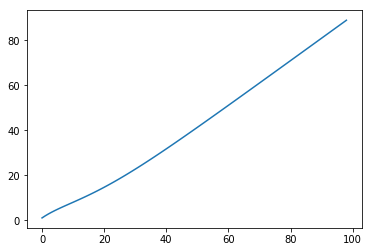

In [229]:
plt.plot(total_pop)
plt.show()